# Esercitazione - Analisi dataset Polidramnios

Dataset: `dataset_polidramnios_10k.csv` (10.000 pazienti).

Colonne:
1. `Eta_anni` - Età (anni)
2. `Numero_Gravidanze_Pregresse` - Numero gravidanze pregresse
3. `Numero_Tagli_Cesarei_Pregressi` - Numero tagli cesarei pregressi
4. `Pressione_Diastolica_mmHg` - Pressione diastolica (mmHg)
5. `Insulina_Sierica_2ore` - Insulina sierica a 2 ore (µU/ml)
6. `Indice_Massa_Corporea` - BMI (kg/m²)
7. `Diabete_Gestazionale` - Diabete gestazionale (0/1)
8. `Diabete_Pregravidico` - Diabete pregravidico (0/1)
9. `Polidramnios` - Polidramnios (0/1) → **target**

Sequenza: 1) pulizia dati 2) analisi esplorativa 3) correlazioni.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dati (il dataset sta in ../dataset/ rispetto a notebooks/)
df = pd.read_csv('../dataset/dataset_polidramnios_10k.csv')
print('Dimensioni:', df.shape)
df.head()

## 1. Pulizia dei dati

Prima ispezione: i tipi delle colonne e i valori mancanti.

In [2]:
df.info()
print('\nValori mancanti (NaN) iniziali:')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Eta_anni                        9737 non-null   str  
 1   Numero_Gravidanze_Pregresse     9762 non-null   str  
 2   Numero_Tagli_Cesarei_Pregressi  9765 non-null   str  
 3   Pressione_Diastolica_mmHg       9746 non-null   str  
 4   Insulina_Sierica_2ore           9741 non-null   str  
 5   Indice_Massa_Corporea           9741 non-null   str  
 6   Diabete_Gestazionale            9765 non-null   str  
 7   Diabete_Pregravidico            9743 non-null   str  
 8   Polidramnios                    10000 non-null  int64
dtypes: int64(1), str(8)
memory usage: 703.3 KB

Valori mancanti (NaN) iniziali:
Eta_anni                          263
Numero_Gravidanze_Pregresse       238
Numero_Tagli_Cesarei_Pregressi    235
Pressione_Diastolica_mmHg         254
Insulina_Sierica_2ore 

### Dati inconsistenti

Quasi tutte le colonne sono di tipo `object`: contengono valori sporchi, ad esempio:
- unità di misura nel testo: `32 anni`, `94 mmHg`, `20.6 kg/m2`
- decimali con la virgola: `60,8`
- numeri scritti a parole: `nove`, `dieci`
- testo al posto del numero: `errore`, `non indicato`, `valore non coerente`
- Sì/No per il diabete: `SI`, `No`, `non noto`

Vanno convertiti in numeri; il testo non interpretabile diventa `NaN`.

In [3]:
import re

parole = {'zero': 0, 'uno': 1, 'due': 2, 'tre': 3, 'quattro': 4, 'cinque': 5,
          'sei': 6, 'sette': 7, 'otto': 8, 'nove': 9, 'dieci': 10}

def to_num(v):
    """Estrae un numero da una stringa sporca; ritorna NaN se non possibile."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower().replace(',', '.')
    if s in parole:                       # numero a parole
        return float(parole[s])
    m = re.search(r'-?\d+\.?\d*', s)      # primo numero presente
    return float(m.group()) if m else np.nan

def to_bin(v):
    """Converte Sì/No/0/1 in 0 o 1; ritorna NaN se non interpretabile."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in ('1', 'si', 's\u00ec', 's'):
        return 1.0
    if s in ('0', 'no', 'n'):
        return 0.0
    return np.nan

num_cols = ['Eta_anni', 'Numero_Gravidanze_Pregresse', 'Numero_Tagli_Cesarei_Pregressi',
            'Pressione_Diastolica_mmHg', 'Insulina_Sierica_2ore', 'Indice_Massa_Corporea']
bin_cols = ['Diabete_Gestazionale', 'Diabete_Pregravidico']

for c in num_cols:
    df[c] = df[c].map(to_num)
for c in bin_cols:
    df[c] = df[c].map(to_bin)

print('Valori mancanti dopo la conversione:')
print(df.isna().sum())

Valori mancanti dopo la conversione:
Eta_anni                          337
Numero_Gravidanze_Pregresse       268
Numero_Tagli_Cesarei_Pregressi    269
Pressione_Diastolica_mmHg         321
Insulina_Sierica_2ore             295
Indice_Massa_Corporea             297
Diabete_Gestazionale              274
Diabete_Pregravidico              287
Polidramnios                        0
dtype: int64


### Range clinici e coerenza logica

Prima di imputare: i valori numerici fuori da intervalli clinici/anagrafici plausibili
diventano `NaN` (verranno imputati dopo). Inoltre correggo un'inconsistenza impossibile:
i **tagli cesarei pregressi** non possono superare le **gravidanze pregresse**.

In [4]:
continue_cols = ['Eta_anni', 'Pressione_Diastolica_mmHg', 'Insulina_Sierica_2ore', 'Indice_Massa_Corporea']
discrete_cols = ['Numero_Gravidanze_Pregresse', 'Numero_Tagli_Cesarei_Pregressi',
                 'Diabete_Gestazionale', 'Diabete_Pregravidico']

# Intervalli clinici/anagrafici plausibili: valori fuori range -> NaN (imputati dopo).
range_validi = {
    'Eta_anni': (14, 55),
    'Numero_Gravidanze_Pregresse': (0, 20),
    'Numero_Tagli_Cesarei_Pregressi': (0, 12),
    'Pressione_Diastolica_mmHg': (40, 130),
    'Insulina_Sierica_2ore': (0, 400),
    'Indice_Massa_Corporea': (14, 60),
}

for c, (lo, hi) in range_validi.items():
    fuori = ((df[c] < lo) | (df[c] > hi)) & df[c].notna()
    print(f'{c}: {int(fuori.sum())} valori fuori range [{lo}, {hi}] -> NaN')
    df.loc[fuori, c] = np.nan

# Coerenza logica: cesarei pregressi <= gravidanze pregresse. Correggo al massimo ammesso.
incoerenti = (
    df['Numero_Tagli_Cesarei_Pregressi'].notna()
    & df['Numero_Gravidanze_Pregresse'].notna()
    & (df['Numero_Tagli_Cesarei_Pregressi'] > df['Numero_Gravidanze_Pregresse'])
)
print(f'\nRighe con cesarei > gravidanze (corrette): {int(incoerenti.sum())}')
df.loc[incoerenti, 'Numero_Tagli_Cesarei_Pregressi'] = df.loc[incoerenti, 'Numero_Gravidanze_Pregresse']

Eta_anni: 20 valori fuori range [14, 55] -> NaN
Numero_Gravidanze_Pregresse: 0 valori fuori range [0, 20] -> NaN
Numero_Tagli_Cesarei_Pregressi: 0 valori fuori range [0, 12] -> NaN
Pressione_Diastolica_mmHg: 24 valori fuori range [40, 130] -> NaN
Insulina_Sierica_2ore: 31 valori fuori range [0, 400] -> NaN
Indice_Massa_Corporea: 6 valori fuori range [14, 60] -> NaN

Righe con cesarei > gravidanze (corrette): 49


### Outlier (clipping)

Sulle variabili continue uso il metodo **IQR**, ma **non rimuovo righe**: limito (clip) i
valori estremi a `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`, intersecato con i range clinici. Evito di
eliminare righe perché la classe positiva è **rara (~2%)** e perderei casi preziosi.

I `NaN` residui **non** vengono imputati qui: l'imputazione avviene dentro la **Pipeline**
(`SimpleImputer`), così il fit è solo sul train e si evita il *data leakage*.

In [5]:
# Outlier: CLIPPING (non rimozione). Limiti = IQR intersecato con i range clinici,
# così non si scende mai sotto i minimi plausibili (es. insulina mai negativa).
for c in continue_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    lo_clin, hi_clin = range_validi[c]
    low, high = max(low, lo_clin), min(high, hi_clin)
    n_clip = int((((df[c] < low) | (df[c] > high)) & df[c].notna()).sum())
    print(f'{c}: {n_clip} valori clippati  (range {low:.1f} - {high:.1f})')
    df[c] = df[c].clip(lower=low, upper=high)

# NB: i NaN residui NON vengono imputati qui -> lo fa la Pipeline (SimpleImputer),
# fit solo sul train, per evitare data leakage.
print('\nRighe (nessuna rimossa):', df.shape[0])
print('NaN residui (imputati poi nella Pipeline):', int(df.isna().sum().sum()))

Eta_anni: 79 valori clippati  (range 16.5 - 44.5)
Pressione_Diastolica_mmHg: 20 valori clippati  (range 48.0 - 96.0)
Insulina_Sierica_2ore: 375 valori clippati  (range 0.0 - 208.0)
Indice_Massa_Corporea: 55 valori clippati  (range 14.0 - 40.8)

Righe (nessuna rimossa): 10000
NaN residui (imputati poi nella Pipeline): 2429


## 2. Analisi esplorativa

Media, mediana e deviazione standard delle variabili.

In [6]:
stats = pd.DataFrame({
    'media': df.mean(),
    'mediana': df.median(),
    'dev_standard': df.std()
}).round(2)
stats

,media,mediana,dev_standard
Eta_anni,30.54,31.0,5.36
Numero_Gravidanze_Pregresse,0.99,1.0,1.18
Numero_Tagli_Cesarei_Pregressi,0.13,0.0,0.38
Pressione_Diastolica_mmHg,71.93,72.0,8.49
Insulina_Sierica_2ore,96.09,87.0,44.84
Indice_Massa_Corporea,26.87,26.8,5.03
Diabete_Gestazionale,0.09,0.0,0.29
Diabete_Pregravidico,0.02,0.0,0.14
Polidramnios,0.03,0.0,0.17


Polidramnios
0    9700
1     300
Name: count, dtype: int64


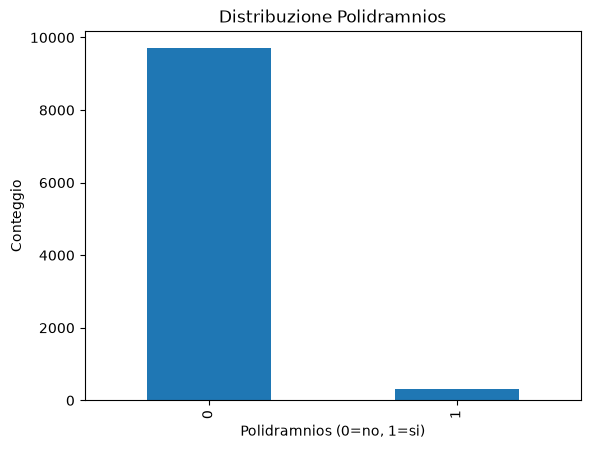

In [7]:
# Distribuzione del target
print(df['Polidramnios'].value_counts())
df['Polidramnios'].value_counts().plot(kind='bar', title='Distribuzione Polidramnios')
plt.xlabel('Polidramnios (0=no, 1=si)'); plt.ylabel('Conteggio'); plt.show()

## 3. Correlazioni

Matrice di correlazione tra tutte le variabili e relazione con il target.

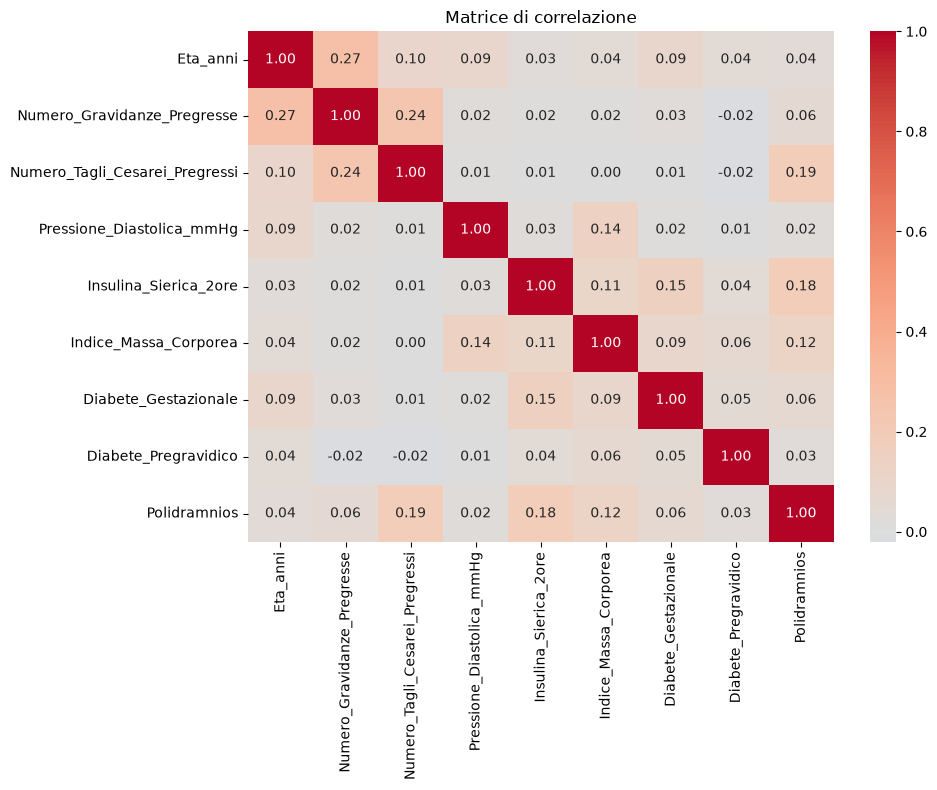

In [8]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice di correlazione')
plt.tight_layout(); plt.show()

Numero_Tagli_Cesarei_Pregressi    0.186
Insulina_Sierica_2ore             0.184
Indice_Massa_Corporea             0.120
Diabete_Gestazionale              0.063
Numero_Gravidanze_Pregresse       0.058
Eta_anni                          0.037
Diabete_Pregravidico              0.028
Pressione_Diastolica_mmHg         0.021
Name: Polidramnios, dtype: float64


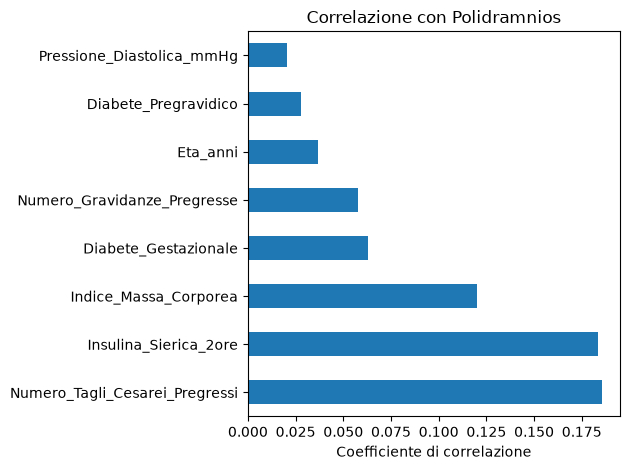

In [9]:
# Correlazione di ogni variabile con il target Polidramnios
corr_target = corr['Polidramnios'].drop('Polidramnios').sort_values(ascending=False)
print(corr_target.round(3))
corr_target.plot(kind='barh', title='Correlazione con Polidramnios')
plt.xlabel('Coefficiente di correlazione'); plt.tight_layout(); plt.show()

## 4. Preprocessore

Imputazione e scaling vivono dentro un `ColumnTransformer`, così il `fit` avviene **solo sul
train** (niente *data leakage*):

- **continue** → imputazione con la **mediana** + `StandardScaler`
- **binarie** → imputazione con il valore **più frequente** (no scaling)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Tutte le numeriche vengono scalate; le binarie solo imputate.
feature_continue = ['Eta_anni', 'Numero_Gravidanze_Pregresse', 'Numero_Tagli_Cesarei_Pregressi',
                    'Pressione_Diastolica_mmHg', 'Insulina_Sierica_2ore', 'Indice_Massa_Corporea']
feature_binarie = ['Diabete_Gestazionale', 'Diabete_Pregravidico']
target = 'Polidramnios'

def crea_preprocessore():
    """ColumnTransformer: imputa + scala le continue, imputa le binarie. Fit solo sul train."""
    pipe_continue = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    pipe_binarie = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])
    return ColumnTransformer([
        ('continue', pipe_continue, feature_continue),
        ('binarie', pipe_binarie, feature_binarie),
    ], remainder='drop')

# Matrice feature / target. Il fit del preprocessore va fatto DOPO lo split, solo sul train.
X = df[feature_continue + feature_binarie]
y = df[target]
preprocessore = crea_preprocessore()
preprocessore

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continue', ...), ('binarie', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

## 5. Addestramento e selezione del modello

Split **stratificato** train/test (la classe positiva è rara). Modello: **Regressione
Logistica** (probabilistica, interpretabile, `class_weight='balanced'`). Ricerca dell'iper-
parametro `C` con `GridSearchCV` su `StratifiedKFold`, ottimizzando il **ROC-AUC** (metrica
adatta a dataset sbilanciati, non l'accuracy).

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression

features = feature_continue + feature_binarie
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.20, stratify=df[target], random_state=42)

# Pipeline = preprocessore + classificatore: il fit (impute/scaling compresi) resta sul train.
pipeline = Pipeline([
    ('preprocessor', crea_preprocessore()),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced')),
])

# Ricerca di C ottimizzando il ROC-AUC in cross-validation stratificata.
param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print('Migliori parametri:', grid.best_params_)
print(f'ROC-AUC medio in CV: {grid.best_score_:.4f}')

Migliori parametri: {'classifier__C': 0.01}
ROC-AUC medio in CV: 0.8576


## 6. Valutazione e salvataggio

Valuto il modello migliore sul **test set** (mai visto). Su dati sbilanciati guardo soprattutto
**recall**, **F1** e **ROC-AUC**, non solo l'accuracy. Salvo poi la pipeline completa con i
metadati (feature, target, soglia, metriche) in un pacchetto `joblib` pronto per il deploy.

In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from pathlib import Path
import joblib

modello = grid.best_estimator_
y_pred = modello.predict(X_test)
y_prob = modello.predict_proba(X_test)[:, 1]   # probabilità della classe positiva

metriche = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob),
}
for k, v in metriche.items():
    print(f'{k:10s}: {v:.4f}')
print('\nMatrice di confusione:\n', confusion_matrix(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

# Pacchetto per il deploy: pipeline + metadati (le feature servono al frontend per l'ordine input).
# models/ sta nella cartella superiore rispetto a notebooks/.
percorso = Path('../models/modello_polidramnios.joblib')
percorso.parent.mkdir(parents=True, exist_ok=True)
pacchetto = {
    'pipeline': modello,
    'features': features,
    'target': target,
    'threshold': 0.50,
    'metrics': {**{k: float(v) for k, v in metriche.items()},
                'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
                'best_params': str(grid.best_params_),
                'best_cv_roc_auc': float(grid.best_score_)},
}
joblib.dump(pacchetto, percorso)
print('\nModello salvato in', percorso)

accuracy  : 0.7990
precision : 0.0909
recall    : 0.6333
f1        : 0.1590
roc_auc   : 0.8250

Matrice di confusione:
 [[1560  380]
 [  22   38]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.80      0.89      1940
           1       0.09      0.63      0.16        60

    accuracy                           0.80      2000
   macro avg       0.54      0.72      0.52      2000
weighted avg       0.96      0.80      0.86      2000


Modello salvato in ..\models\modello_polidramnios.joblib
